In [2]:
%cd ..

/home/bhchen/LearnKalmanGain


In [3]:
import torch
import matplotlib.pyplot as plt

0.4907919466495514
0.10977187752723694
0.4587821662425995
0.10305497795343399
0.45479726791381836
0.10327000170946121


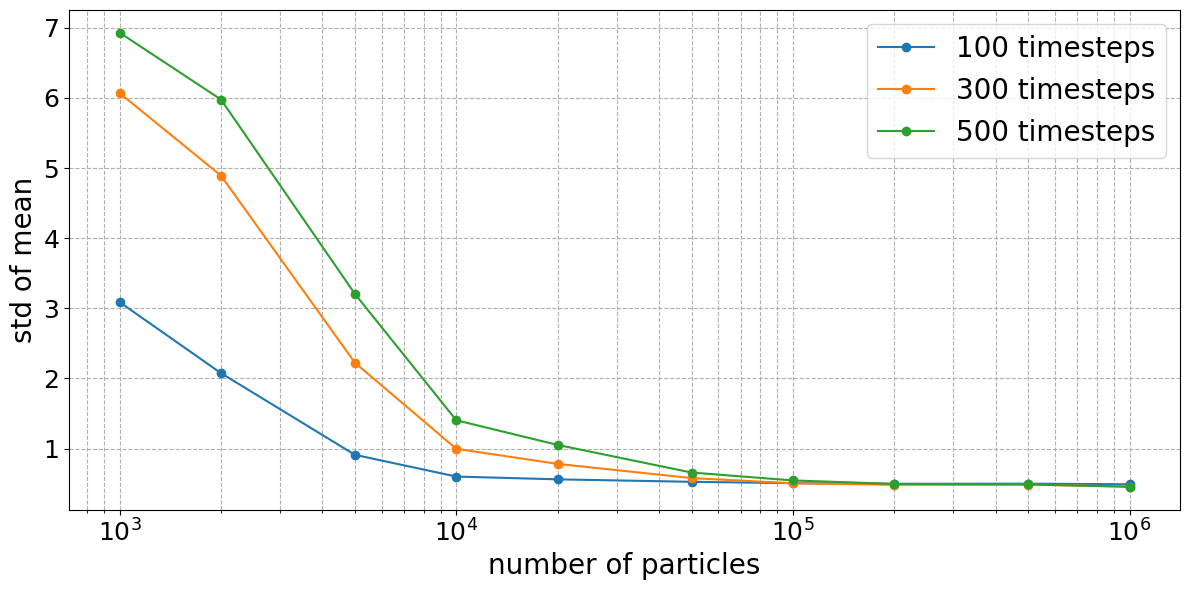

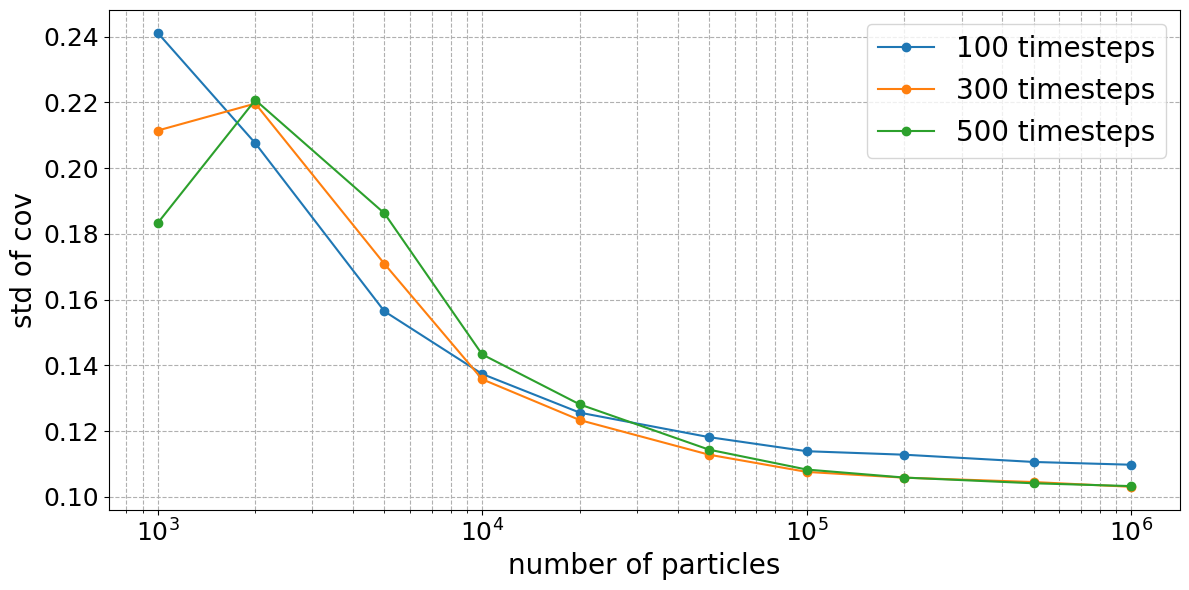

In [4]:
pf_N_list = [1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000, 500000, 1000000]
seed_list = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 42]
max_t_list = [100, 300, 500]

fig1 = plt.figure(figsize=(12, 6))
fig2 = plt.figure(figsize=(12, 6))
ax1 = fig1.add_subplot(1, 1, 1)
ax2 = fig2.add_subplot(1, 1, 1)
ax1.set_xscale('log')
ax2.set_xscale('log')

for max_t in max_t_list:
    std_pf_N_mean_list = []
    std_pf_N_cov_list = []
    for pf_N in pf_N_list:
        mean_list = []
        cov_list =[]
        for seed in seed_list:
            data_name = f"data/lorenz63/pf_results_sigma_y_1.0_batch_64_len_500_pfN_{pf_N}_{seed}.pt"
            data = torch.load(data_name, weights_only=True)
            mean_list.append(data[0]['means'])
            cov_list.append(data[0]['covs'])
        mean_tensor = torch.stack(mean_list)[:, :max_t, :, :]
        cov_tensor = torch.stack(cov_list)[:, :max_t, :, :]
        std_pf_N_mean_list.append(torch.std(mean_tensor, dim=0).mean().item())
        std_pf_N_cov_list.append(torch.std(cov_tensor, dim=0).mean().item())
        if pf_N == 1000000:
            print(std_pf_N_mean_list[-1])
            print(std_pf_N_cov_list[-1])
            
    ax1.plot(pf_N_list, std_pf_N_mean_list, marker='o', linestyle='-', label=f"{max_t} timesteps")
    ax2.plot(pf_N_list, std_pf_N_cov_list, marker='o', linestyle='-', label=f"{max_t} timesteps")

ax1.set_xlabel("number of particles", fontsize=20)
ax1.set_ylabel("std of mean", fontsize=20)
ax1.legend(fontsize=20)
ax1.tick_params(axis='both', which='major', labelsize=18)
ax1.grid(True, which="both", ls="--")

ax2.set_xlabel("number of particles", fontsize=20)
ax2.set_ylabel("std of cov", fontsize=20)
ax2.legend(fontsize=20)
ax2.tick_params(axis='both', which='major', labelsize=18)
ax2.grid(True, which="both", ls="--")

fig1.tight_layout()
fig2.tight_layout()

plt.show()
